In [1]:
# Usual imports
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as T
from rich.progress import Progress
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

# RobustBench
import robustbench
from robustbench.utils import load_model
from secml.utils import fm
from secml import settings


## CUDA

In [2]:
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA available: True
GPU name: NVIDIA GeForce RTX 4090


## Utilities

In [3]:
class ProbRegressionWrapper(nn.Module):
    def __init__(self, classifier):
        super().__init__()
        self.classifier = classifier  # pretrained classifier

    def forward(self, x):
        logits = self.classifier(x)
        probs = F.softmax(logits, dim=1)
        return probs
    
def load_cifar10_splits(
    n_train=1000,
    n_cal=500,
    n_test=2000
):
    transform = T.ToTensor()

    # Load datasets
    trainset = torchvision.datasets.CIFAR10(
        root='./data', train=True, download=True, transform=transform
    )

    # Random selection (only indices)
    perm_train = torch.randperm(len(trainset))

    idx_train = perm_train[:n_train]
    idx_cal = perm_train[n_train:n_train+n_cal]
    idx_test = perm_train[:n_test]

    # Extract only needed samples (NO full dataset stacking)
    X_train = torch.stack([trainset[i][0] for i in idx_train])
    y_train = torch.tensor([trainset[i][1] for i in idx_train])

    X_cal = torch.stack([trainset[i][0] for i in idx_cal])
    y_cal = torch.tensor([trainset[i][1] for i in idx_cal])

    X_test = torch.stack([trainset[i][0] for i in idx_test])
    y_test = torch.tensor([trainset[i][1] for i in idx_test])

    return (X_train, y_train), (X_cal, y_cal), (X_test, y_test)

## Dataset

### CIFAR_10

In [4]:
(train_X, train_y), (cal_X, cal_y), (test_X, test_y) = load_cifar10_splits(
    n_train=100, n_cal=100, n_test=100
)

train_X = train_X.to(device)
train_y = train_y.to(device)

cal_X = cal_X.to(device)
cal_y = cal_y.to(device)

test_X = test_X.to(device)
test_y = test_y.to(device)

### One-hot encode 
#### (from classification to regression)

In [5]:
num_classes = 10
train_y_oh = F.one_hot(train_y, num_classes=num_classes).float()
cal_y_oh = F.one_hot(cal_y, num_classes=num_classes).float()
test_y_oh = F.one_hot(test_y, num_classes=num_classes).float()

## RobustBench

### Regression on Correct-Class Probability

We treat the pretrained classification model as a regressor on the **true-class probability**.  
The regression target is the logit of the true class probability:


$$ y_{\text{reg}} = \text{logit}\big(p_{\text{true class}}(x)\big) = \log \frac{p_{\text{true class}}(x)}{1 - p_{\text{true class}}(x)} $$ 


The regressor $ g_\phi(x) $ predicts this real value:

$$
\hat{y}_{\text{reg}} = g_\phi(x) \approx y_{\text{reg}}
$$

Performance can be evaluated using MSE on the predicted correct-class probability, classification accuracy, and calibration metrics.


In [6]:
#L2#
#Wang2023Better_WRN-70-16

#Linf#
#Andriushchenko2020Understanding

In [6]:
output_dir = fm.join(settings.SECML_MODELS_DIR, 'robustbench')

### Load a model

In [7]:
model_wang = load_model('Wang2023Better_WRN-70-16', norm='L2', model_dir=output_dir).to(device)

reg_wang = ProbRegressionWrapper(model_wang).to(device)

In [8]:
with torch.no_grad():
    probs_cal = reg_wang(cal_X)  # (n_cal, 10)
    correct_probs_cal = probs_cal[range(len(cal_y)), cal_y]  # (n_cal,)
    
    probs_test = reg_wang(test_X)
    correct_probs_test = probs_test[range(len(test_y)), test_y]

### Evaluate the model

MSE (correct class prob → 1): 0.024348
Accuracy: 100.00%


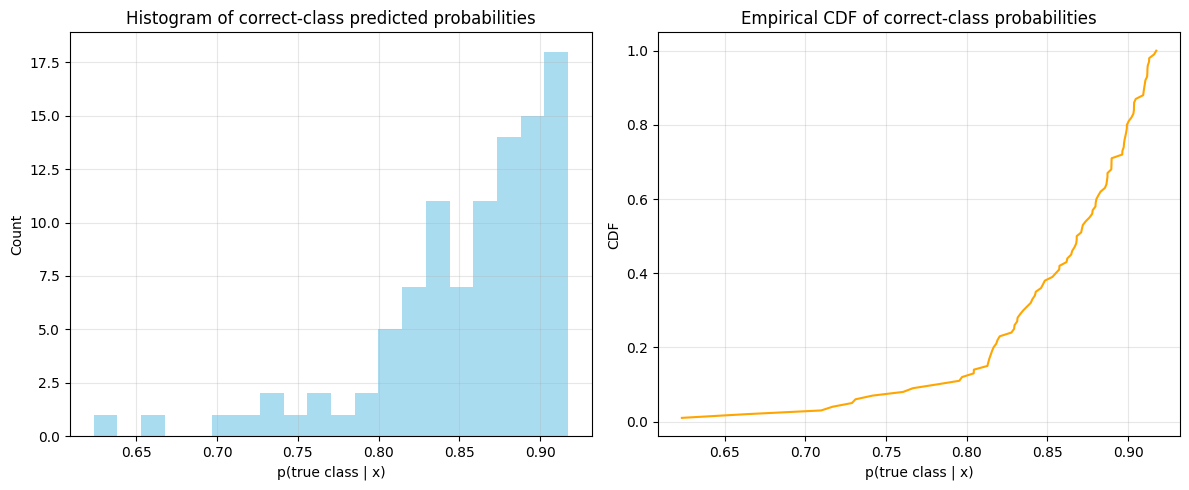

In [9]:
reg_wang.eval()

batch_size = 128
all_probs = []

# --------------------------------------------------
# Forward pass (batched)
# --------------------------------------------------
with torch.no_grad():
    for i in range(0, len(test_X), batch_size):
        batch = test_X[i:i+batch_size].to(device)
        p = reg_wang(batch)
        all_probs.append(p)
        
probs = torch.cat(all_probs, dim=0)  # (n_samples, n_classes)

# --------------------------------------------------
# Correct-class probabilities
# --------------------------------------------------
correct_probs = probs[range(len(test_y)), test_y]

# --------------------------------------------------
# MSE on correct-class probability
# --------------------------------------------------
mse = ((correct_probs - 1) ** 2).mean().item()
print(f"MSE (correct class prob → 1): {mse:.6f}")

# --------------------------------------------------
# Classification accuracy
# --------------------------------------------------
preds = probs.argmax(dim=1)
acc = (preds == test_y).float().mean().item()
print(f"Accuracy: {acc*100:.2f}%")


# --------------------------------------------------
# Histogram and CDF of correct-class probabilities
# --------------------------------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.hist(correct_probs.cpu().numpy(), bins=20, color='skyblue', alpha=0.7)
plt.title("Histogram of correct-class predicted probabilities")
plt.xlabel("p(true class | x)")
plt.ylabel("Count")
plt.grid(alpha=0.3)

plt.subplot(1,2,2)
sorted_probs, counts = torch.sort(correct_probs)
cdf = torch.arange(1, len(sorted_probs)+1) / len(sorted_probs)
plt.plot(sorted_probs.cpu().numpy(), cdf.numpy(), color='orange')
plt.title("Empirical CDF of correct-class probabilities")
plt.xlabel("p(true class | x)")
plt.ylabel("CDF")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Attack

In [10]:
def fgsm_attack_regression_batched(model, X, y, epsilon=0.05, batch_size=32):
    model.eval()
    X_adv_list = []
    
    for i in range(0, len(X), batch_size):
        xb = X[i:i+batch_size].clone().detach().to(device)
        yb = y[i:i+batch_size].to(device)

        xb.requires_grad = True

        # Forward
        probs = model(xb)  # shape (B,10)
        correct_probs = probs[range(len(yb)), yb]

        # Loss = push correct class prob → 1
        loss = ((correct_probs - 1)**2).mean()

        # Compute gradient
        model.zero_grad()
        loss.backward()

        # FGSM step
        xb_adv = xb + epsilon * xb.grad.sign()
        xb_adv = torch.clamp(xb_adv, 0, 1).detach()

        X_adv_list.append(xb_adv.cpu())  # move OFF GPU immediately

        # Free memory
        del xb, yb, probs, correct_probs, loss, xb_adv
        torch.cuda.empty_cache()

    return torch.cat(X_adv_list, dim=0)


### Run the attack

In [11]:
epsilon = 1

cal_X_adv  = fgsm_attack_regression_batched(reg_wang, cal_X,  cal_y,  epsilon).to(device)
test_X_adv = fgsm_attack_regression_batched(reg_wang, test_X, test_y, epsilon).to(device)


### Post-attack evaluation

MSE after attack (correct class prob → 1): 0.752249
Accuracy after attack: 21.00%


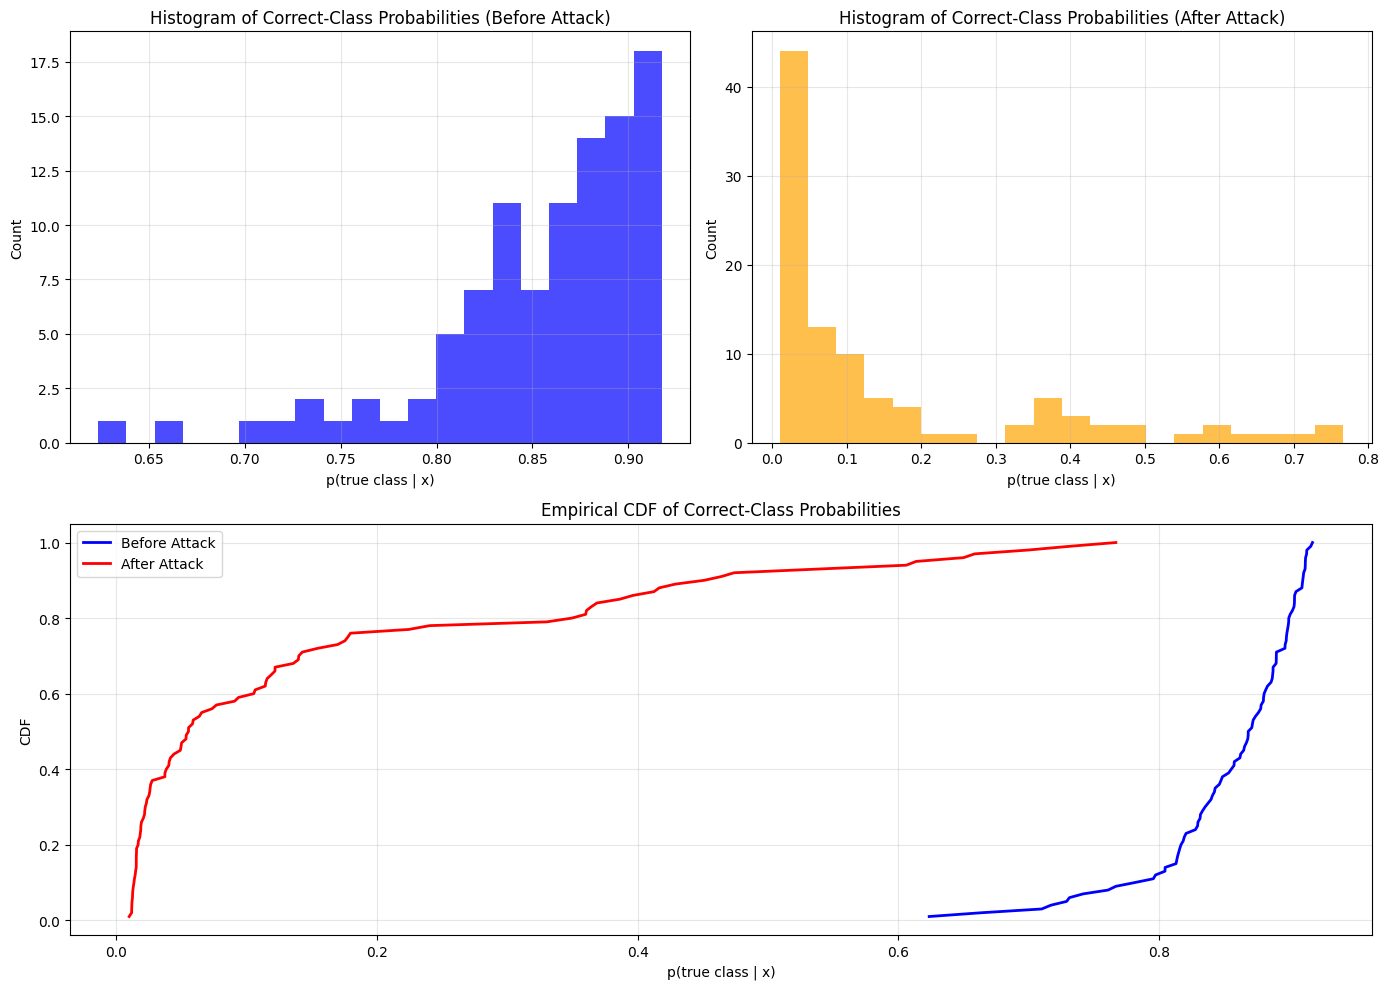

In [12]:
reg_wang.eval()
batch_size = 128
all_probs_adv = []

with torch.no_grad():
    for i in range(0, len(test_X_adv), batch_size):
        batch = test_X_adv[i:i+batch_size].to(device)
        p = reg_wang(batch)
        all_probs_adv.append(p)

probs_adv = torch.cat(all_probs_adv, dim=0)

# MSE on correct-class probability
correct_probs_adv = probs_adv[range(len(test_y)), test_y]
mse_adv = ((correct_probs_adv - 1)**2).mean().item()
print(f"MSE after attack (correct class prob → 1): {mse_adv:.6f}")

# Classification accuracy
preds_adv = probs_adv.argmax(dim=1)
acc_adv = (preds_adv == test_y.to(device)).float().mean().item()
print(f"Accuracy after attack: {acc_adv*100:.2f}%")

# Pre-attack
sorted_probs_pre = np.sort(correct_probs.cpu().numpy())
cdf_pre = np.arange(1, len(sorted_probs_pre)+1) / len(sorted_probs_pre)

# Post-attack
sorted_probs_post = np.sort(correct_probs_adv.cpu().numpy())
cdf_post = np.arange(1, len(sorted_probs_post)+1) / len(sorted_probs_post)

# Create figure with gridspec
fig = plt.figure(figsize=(14, 10))
gs = GridSpec(2, 2, figure=fig, height_ratios=[1, 1])

# -------------------------------------------------
# 1. Histogram - Pre-attack
ax0 = fig.add_subplot(gs[0, 0])
ax0.hist(correct_probs.cpu().numpy(), bins=20, alpha=0.7, color='blue')
ax0.set_title("Histogram of Correct-Class Probabilities (Before Attack)")
ax0.set_xlabel("p(true class | x)")
ax0.set_ylabel("Count")
ax0.grid(alpha=0.3)

# 2. Histogram - Post-attack
ax1 = fig.add_subplot(gs[0, 1])
ax1.hist(correct_probs_adv.cpu().numpy(), bins=20, alpha=0.7, color='orange')
ax1.set_title("Histogram of Correct-Class Probabilities (After Attack)")
ax1.set_xlabel("p(true class | x)")
ax1.set_ylabel("Count")
ax1.grid(alpha=0.3)

# 3. Empirical CDF comparison (spans both columns)
ax2 = fig.add_subplot(gs[1, :])
ax2.plot(sorted_probs_pre, cdf_pre, color='blue', linewidth=2, label='Before Attack')
ax2.plot(sorted_probs_post, cdf_post, color='red', linewidth=2, label='After Attack')
ax2.set_title("Empirical CDF of Correct-Class Probabilities")
ax2.set_xlabel("p(true class | x)")
ax2.set_ylabel("CDF")
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

## CP SEI ARRIVATO QUI !!!

In [13]:
def nonconformity_score(y_true, y_pred, u=None):
    """
    Compute nonconformity scores for regression CP, optionally using an uncertainty scalar.

    Args:
        y_true: torch.Tensor of shape (n,)  -- true regression targets
        y_pred: torch.Tensor of shape (n,)  -- predicted regression outputs
        u: torch.Tensor of shape (n,), optional -- per-example uncertainty (e.g., predicted std or residual)
    
    Returns:
        scores: torch.Tensor of shape (n,)  -- nonconformity scores
    """
    residuals = torch.abs(y_pred - y_true)
    
    if u is not None:
        scores = residuals / u
        
    else:
        scores = residuals
    
    return scores


In [14]:
def cp_interval_width(u, qhat):
    """
    Computes conformal prediction interval widths.
    
    Args:
        u:    array-like of shape (n,) -- uncertainty scalar u(x)
        qhat: float                   -- conformal quantile

    Returns:
        width: array of shape (n,) -- interval widths
    """
    u = torch.as_tensor(u, dtype=torch.float32)
    return 2 * u * qhat

In [23]:
u_cal

tensor([0.0234, 0.0308, 0.0091, 0.0149, 0.0227, 0.0100, 0.0099, 0.0203, 0.0132,
        0.0103, 0.0124, 0.1144, 0.0180, 0.0355, 0.0072, 0.0679, 0.0556, 0.0122,
        0.0378, 0.0112, 0.0427, 0.0088, 0.1771, 0.1105, 0.0568, 0.0064, 0.0073,
        0.0240, 0.0739, 0.0440, 0.0118, 0.0142, 0.0170, 0.0302, 0.0305, 0.0073,
        0.0104, 0.0423, 0.0526, 0.0209, 0.0077, 0.0457, 0.0475, 0.0176, 0.0118,
        0.0296, 0.0316, 0.0217, 0.1157, 0.2531, 0.0105, 0.0088, 0.0073, 0.0239,
        0.0085, 0.0151, 0.0236, 0.0081, 0.0094, 0.0764, 0.0078, 0.0268, 0.0252,
        0.0173, 0.0081, 0.0170, 0.0642, 0.0363, 0.0082, 0.0080, 0.0107, 0.0118,
        0.1305, 0.0124, 0.0083, 0.0361, 0.0208, 0.0271, 0.0083, 0.1194, 0.0179,
        0.0278, 0.0694, 0.0107, 0.0130, 0.0679, 0.0113, 0.1837, 0.0073, 0.0080,
        0.0844, 0.0087, 0.0441, 0.0309, 0.0085, 0.0444, 0.0745, 0.0161, 0.0099,
        0.0082], device='cuda:0')

In [24]:
score_cal

tensor([ 6.5433,  5.6972, 10.4664,  8.1835,  6.6425,  9.9921, 10.0265,  7.0251,
         8.7075,  9.8667,  8.9807,  2.9571,  7.4623,  5.3066, 11.7941,  3.8371,
         4.2422,  9.0482,  5.1431,  9.4652,  4.8416, 10.6734,  2.3765,  3.0077,
         4.1952, 12.5314, 11.6826,  6.4600,  3.6778,  4.7667,  9.2197,  8.3992,
         7.6674,  5.7587,  5.7252, 11.7331,  9.7832,  4.8603,  4.3618,  6.9153,
        11.3782,  4.6771,  4.5892,  7.5423,  9.2160,  5.8089,  5.6293,  6.7891,
         2.9397,  1.9876,  9.7644, 10.6615, 11.7072,  6.4725, 10.8433,  8.1267,
         6.5034, 11.0855, 10.3317,  3.6177, 11.3060,  6.1075,  6.2992,  7.5962,
        11.1305,  7.6797,  3.9458,  5.2466, 11.0335, 11.2146,  9.6842,  9.2009,
         2.7686,  8.9765, 10.9692,  5.2634,  6.9289,  6.0751, 10.9607,  2.8943,
         7.4732,  5.9926,  3.7953,  9.6771,  8.7638,  3.8382,  9.3909,  2.3330,
        11.7121, 11.1469,  3.4414, 10.6925,  4.7634,  5.6871, 10.8348,  4.7446,
         3.6649,  7.8839, 10.0603, 11.06

### Clean scores

In [22]:
with torch.no_grad():

    probs_cal = reg_wang(cal_X)  # (n_cal, 10)
    y_pred_cal = probs_cal[range(len(cal_y)), cal_y]  # (n_cal,)
    u_cal = ((y_pred_cal - 1) ** 2)#.mean().item()  # or some other heuristic
    score_cal = nonconformity_score(1.0, torch.tensor(y_pred_cal, dtype=torch.float32), u=u_cal)
    
    probs_test = reg_wang(test_X)
    y_pred_test = probs_test[range(len(test_y)), test_y]
    u_test = ((y_pred_test - 1) ** 2)#.mean().item()  # or some other heuristic
    score_test = nonconformity_score(1.0, torch.tensor(y_pred_test, dtype=torch.float32), u = u_test)


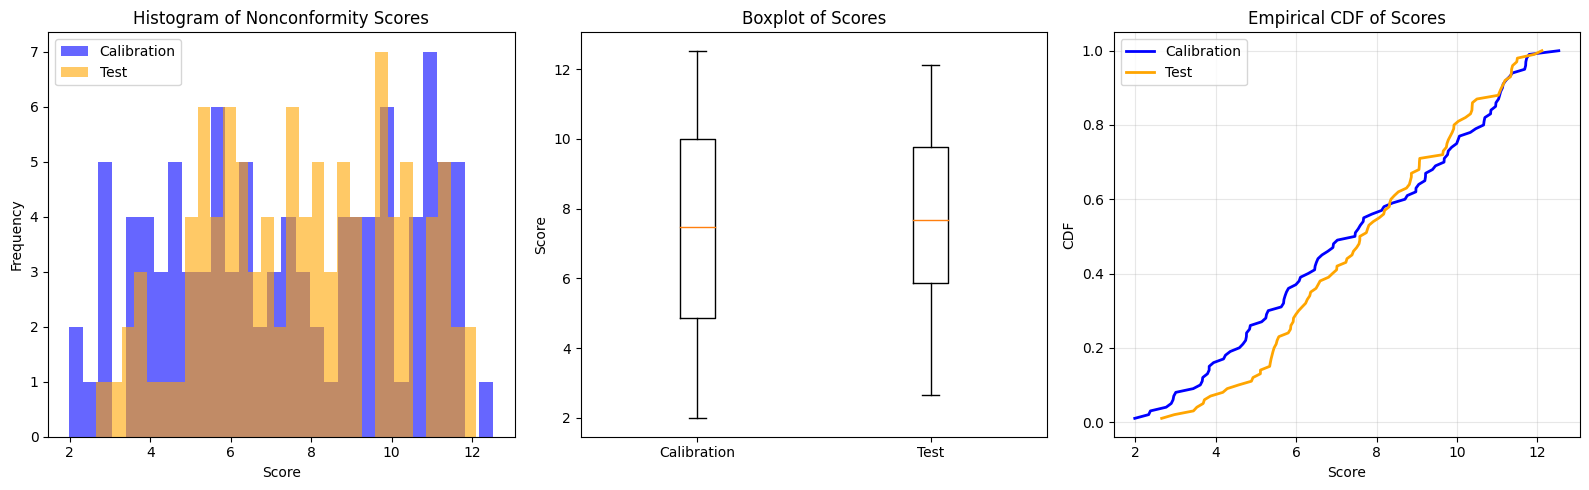

In [25]:
# Convert to numpy if not already
score_cal_np = score_cal.cpu().numpy() if hasattr(score_cal, "cpu") else np.array(score_cal)
score_test_np = score_test.cpu().numpy() if hasattr(score_test, "cpu") else np.array(score_test)

# Plot
plt.figure(figsize=(16, 5))

# 1. Histogram
plt.subplot(1, 3, 1)
plt.hist(score_cal_np, bins=30, alpha=0.6, label="Calibration", color='blue')
plt.hist(score_test_np, bins=30, alpha=0.6, label="Test", color='orange')
plt.title("Histogram of Nonconformity Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

# 2. Boxplot
plt.subplot(1, 3, 2)
plt.boxplot([score_cal_np, score_test_np], labels=["Calibration", "Test"])
plt.title("Boxplot of Scores")
plt.ylabel("Score")

# 3. Empirical CDF
plt.subplot(1, 3, 3)
sorted_cal = np.sort(score_cal_np)
sorted_test = np.sort(score_test_np)
cdf_cal = np.arange(1, len(sorted_cal)+1) / len(sorted_cal)
cdf_test = np.arange(1, len(sorted_test)+1) / len(sorted_test)
plt.plot(sorted_cal, cdf_cal, label="Calibration", color='blue', linewidth=2)
plt.plot(sorted_test, cdf_test, label="Test", color='orange', linewidth=2)
plt.title("Empirical CDF of Scores")
plt.xlabel("Score")
plt.ylabel("CDF")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### CP on calibration

In [46]:
alpha = 0.1# for 90% CP
n_cal = len(score_cal)
score_cal_tensor = torch.tensor(score_cal, dtype=torch.float32)
q_level = (n_cal + 1) * (1 - alpha) / n_cal
qhat = torch.quantile(score_cal_tensor,np.floor((n_cal+1)*(1-alpha))/n_cal)

print(f"Conformal quantile q̂: {qhat:.4f}")

y_pred_cal_tensor = torch.tensor(y_pred_cal, dtype=torch.float32)

# Interval width
radius = u_cal * qhat

# Final conformal interval:
lower = y_pred_cal - radius
upper = y_pred_cal + radius

# -------------------------------
# 3. Evaluate empirical coverage
# -------------------------------
y_true_cal_tensor = torch.ones_like(y_pred_cal_tensor)  # since target = 1.0 for "correct class"
coverage = ((lower <= y_true_cal_tensor) & (y_true_cal_tensor <= upper)).float().mean().item()
print(f"Empirical coverage: {coverage*100:.2f}%")

widths = cp_interval_width(u_cal, qhat)

cp_size = widths.mean().item()
print("CP size =", cp_size)

Conformal quantile q̂: 11.1321
Empirical coverage: 90.00%
CP size = 0.7681330442428589


### CP on test

In [48]:
alpha = 0.05  # for 90% CP
n_cal = len(score_cal)
score_cal_tensor = torch.tensor(score_cal, dtype=torch.float32)
q_level = (n_cal + 1) * (1 - alpha) / n_cal
qhat = torch.quantile(score_cal_tensor,np.floor((n_cal+1)*(1-alpha))/n_cal)

print(f"Conformal quantile q̂: {qhat:.4f}")

y_pred_test_tensor = torch.tensor(y_pred_test, dtype=torch.float32)

# Interval width
radius = u_test * qhat

# Final conformal interval:
lower = y_pred_test - radius
upper = y_pred_test + radius

# -------------------------------
# 3. Evaluate empirical coverage
# -------------------------------
y_true_test_tensor = torch.ones_like(y_pred_test_tensor)  # since target = 1.0 for "correct class"
coverage = ((lower <= y_true_test_tensor) & (y_true_test_tensor <= upper)).float().mean().item()
print(f"Empirical coverage: {coverage*100:.2f}%")

widths_test = cp_interval_width(u_cal, qhat)

cp_size_test = widths_test.mean().item()
print("CP size =", cp_size_test)

Conformal quantile q̂: 11.6838
Empirical coverage: 98.00%
CP size = 0.8061984181404114


### Attacked scores

In [49]:
with torch.no_grad():

    probs_cal_adv = reg_wang(cal_X_adv)  # (n_cal, 10)
    y_pred_cal_adv = probs_cal_adv[range(len(cal_y)), cal_y]  # (n_cal,)
    u_cal_adv = ((y_pred_cal_adv - 1) ** 2)#.mean().item()  # or some other heuristic
    score_cal_adv = nonconformity_score(1.0, torch.tensor(y_pred_cal_adv, dtype=torch.float32), u=u_cal_adv)
    
    probs_test_adv = reg_wang(test_X_adv)
    y_pred_test_adv = probs_test_adv[range(len(test_y)), test_y]
    u_test_adv = ((y_pred_test_adv - 1) ** 2)#.mean().item()  # or some other heuristic
    score_test_adv = nonconformity_score(1.0, torch.tensor(y_pred_test_adv, dtype=torch.float32), u = u_test_adv)


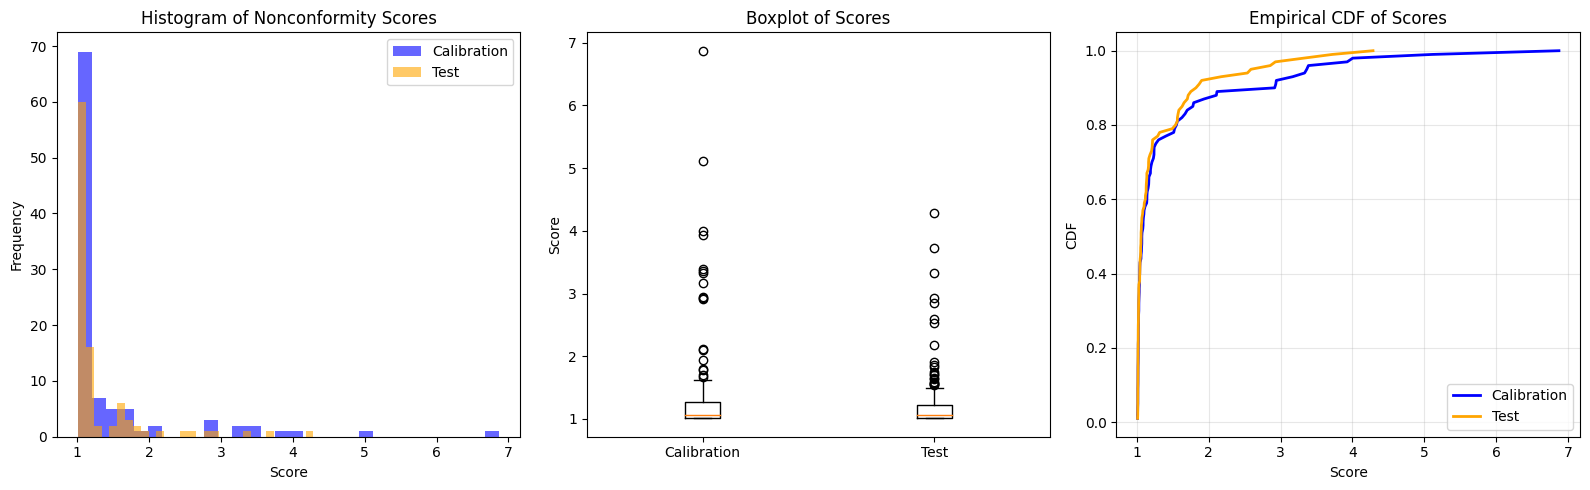

In [50]:
# Convert to numpy if not already
score_cal_adv_np = score_cal_adv.cpu().numpy() if hasattr(score_cal_adv, "cpu") else np.array(score_cal)
score_test_adv_np = score_test_adv.cpu().numpy() if hasattr(score_test_adv, "cpu") else np.array(score_test)

# Plot
plt.figure(figsize=(16, 5))

# 1. Histogram
plt.subplot(1, 3, 1)
plt.hist(score_cal_adv_np, bins=30, alpha=0.6, label="Calibration", color='blue')
plt.hist(score_test_adv_np, bins=30, alpha=0.6, label="Test", color='orange')
plt.title("Histogram of Nonconformity Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.legend()

# 2. Boxplot
plt.subplot(1, 3, 2)
plt.boxplot([score_cal_adv_np, score_test_adv_np], labels=["Calibration", "Test"])
plt.title("Boxplot of Scores")
plt.ylabel("Score")

# 3. Empirical CDF
plt.subplot(1, 3, 3)
sorted_cal = np.sort(score_cal_adv_np)
sorted_test = np.sort(score_test_adv_np)
cdf_cal = np.arange(1, len(sorted_cal)+1) / len(sorted_cal)
cdf_test = np.arange(1, len(sorted_test)+1) / len(sorted_test)
plt.plot(sorted_cal, cdf_cal, label="Calibration", color='blue', linewidth=2)
plt.plot(sorted_test, cdf_test, label="Test", color='orange', linewidth=2)
plt.title("Empirical CDF of Scores")
plt.xlabel("Score")
plt.ylabel("CDF")
plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

### Vanilla CP

In [53]:
alpha = 0.1  # for 90% CP
n_cal = len(score_cal)
score_cal_tensor = torch.tensor(score_cal, dtype=torch.float32)
q_level = (n_cal + 1) * (1 - alpha) / n_cal
qhat = torch.quantile(score_cal_tensor,np.ceil((n_cal+1)*(1-alpha))/n_cal)

print(f"Conformal quantile q̂: {qhat:.4f}")

y_pred_test_tensor = torch.tensor(y_pred_test, dtype=torch.float32)

# Interval width
radius = u_test * qhat

# Final conformal interval:
lower = y_pred_test_adv - radius
upper = y_pred_test_adv + radius

# -------------------------------
# 3. Evaluate empirical coverage
# -------------------------------
y_true_test_tensor = torch.ones_like(y_pred_test_tensor)  # since target = 1.0 for "correct class"
coverage = ((lower <= y_true_test_tensor) & (y_true_test_tensor <= upper)).float().mean().item()
print(f"Empirical coverage: {coverage*100:.2f}%")

Conformal quantile q̂: 11.1530
Empirical coverage: 5.00%


In [50]:
score_cal_adv.mean().item()

1.1250568628311157

In [54]:
q_level

0.9008999999999999

In [44]:
alpha = 0.1 # for 90% CP
n_cal = len(score_cal)
score_cal_tensor_adv = torch.tensor(score_cal_adv, dtype=torch.float32)
q_level = (n_cal + 1) * (1 - alpha) / n_cal
qhat_adv = torch.quantile(score_cal_tensor_adv,np.floor((n_cal+1)*(1-alpha))/n_cal)

print(f"Conformal quantile q̂: {qhat_adv:.4f}")

y_pred_cal_adv_tensor = torch.tensor(y_pred_cal_adv, dtype=torch.float32)

# Interval width
radius_adv = u_test_adv * qhat_adv

# Final conformal interval:
lower_adv = y_pred_cal_adv - radius_adv
upper_adv = y_pred_cal_adv + radius_adv

# -------------------------------
# 3. Evaluate empirical coverage
# -------------------------------
y_true_cal_adv_tensor = torch.ones_like(y_pred_cal_adv_tensor)  # since target = 1.0 for "correct class"
coverage_adv = ((lower_adv <= y_true_cal_adv_tensor) & (y_true_cal_adv_tensor <= upper_adv)).float().mean().item()
print(f"Empirical coverage: {coverage_adv*100:.2f}%")

widths_cal_adv = cp_interval_width(u_cal_adv, qhat_adv)

cp_size_cal_adv = widths_cal_adv.mean().item()
print("CP size =", cp_size_cal_adv)

Conformal quantile q̂: 2.9185
Empirical coverage: 91.00%
CP size = 4.214174747467041


In [45]:
alpha = 0.01  # for 90% CP
n_cal = len(score_cal)
score_cal_tensor_adv = torch.tensor(score_cal_adv, dtype=torch.float32)
q_level = (n_cal + 1) * (1 - alpha) / n_cal
qhat_adv = torch.quantile(score_cal_tensor_adv,np.ceil((n_cal+1)*(1-alpha))/n_cal)

print(f"Conformal quantile q̂: {qhat_adv:.4f}")

y_pred_test_adv_tensor = torch.tensor(y_pred_test_adv, dtype=torch.float32)

# Interval width
radius_adv_test = u_cal_adv * qhat_adv

# Final conformal interval:
lower_adv_test = y_pred_test_adv - radius_adv_test
upper_adv_test = y_pred_test_adv + radius_adv_test

# -------------------------------
# 3. Evaluate empirical coverage
# -------------------------------
y_true_test_adv_tensor = torch.ones_like(y_pred_test_adv_tensor)  # since target = 1.0 for "correct class"
coverage_adv_test = ((lower_adv_test <= y_true_test_adv_tensor) & (y_true_test_adv_tensor <= upper_adv_test)).float().mean().item()
print(f"Empirical coverage: {coverage_adv_test*100:.2f}%")

widths_test_adv = cp_interval_width(u_cal_adv, qhat_adv)

cp_size_test_adv = widths_test_adv.mean().item()
print("CP size =", cp_size_test_adv)

Conformal quantile q̂: 6.8727
Empirical coverage: 89.00%
CP size = 9.924009323120117


In [34]:
(lower_adv_test <= y_true_test_tensor)

tensor([True, True, True,  ..., True, True, True], device='cuda:0')

In [66]:
u_cal_adv

0.7504371404647827

In [65]:
u_test_adv

0.7398667931556702